# EMRI Kerr Waveform – LISA SNR Analysis (Paper-Level Pipeline)

This notebook automatically:

1. Generates an EMRI waveform
2. Applies a phase transition correction
3. Computes residual waveform
4. Converts to frequency domain
5. Computes characteristic strain
6. Applies LISA sensitivity curve
7. Computes Signal-to-Noise Ratio (SNR)
8. Computes waveform mismatch
9. **Automatically saves all plots and results**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq


## Physical constants

In [ ]:
# Physical constants
G = 6.67430e-11          # gravitational constant (m^3/kg/s^2)
c = 299792458            # lightspeed (m/s)
Msun = 1.98847e30        # solar mass (kg)
pc = 3.085677581e16      # parsec (m)

## System parameters

In [ ]:
# System parameters for the EMRI
M = 2e5 * Msun           # mass of central black hole (kg)
mu = 1.4 * Msun          # mass of compact object (kg)
spin = 0.9               # dimensionless spin of the central black hole
distance = 1e9 * pc      # luminosity distance to the source (m)


## Inspiral frequency evolution

In [ ]:
# Time array settings
T = 0.02*86400         # total observation duration (s) (approxoimately 0.02 days)
N = 200000               # number of time samples
t = np.linspace(-T, 0, N)   # time array from -T to 0 (s)

# Frequency evolution from f_start to f_end over the range of time
f_start = 1e-4           # initial frequency (Hz)
f_end = 0.036            # ending frequency (Hz)
freq_t = f_start+(f_end - f_start)*(t+T)/T   # linear frequency sweep


## Baseline waveform

In [8]:
# Phase and amplitude for a simple baseline waveform
phase = 2*np.pi*np.cumsum(freq_t)*(t[1]-t[0]) # integral phase
amp = 1e-24*(freq_t/f_start)**(2/3) # Amplitude scale

h_baseline = amp*np.sin(phase) # Wave function of the baseline


## Phase transition correction

In [ ]:
#Phase transition adjustment 
phase_shift = 0.3*np.exp(t/1500) # Time dependent phase shift

h_transition = h_baseline*np.cos(phase_shift) - np.sin(phase_shift)*h_baseline
# Phase-transition-applied wave form

## Residual waveform

In [ ]:
h_residual = h_transition - h_baseline
# Compute residual as the difference between transition and baseline waveforms 


## Time-domain waveform plot

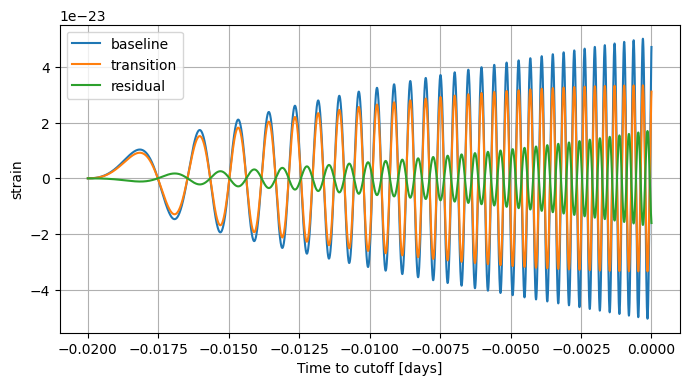

In [ ]:
# Plot the strain of baseline, transition, and residual waveforms in the domain of time 
plt.figure(figsize=(8,4))

plt.plot(t/86400, h_baseline, label="baseline")
plt.plot(t/86400, h_transition, label="transition")
plt.plot(t/86400, h_residual, label="residual")

plt.xlabel("Time to cutoff [days]")
plt.ylabel("strain")
plt.legend()
plt.grid()

plt.savefig("waveform_time_domain.png", dpi=300)
plt.show()


## FFT → frequency domain

In [13]:
#Frequency-domain transformation
dt = t[1]-t[0]

freq = rfftfreq(N, dt)

#Real FFT of the waveforms
H_baseline = rfft(h_baseline)
H_transition = rfft(h_transition)
H_residual = rfft(h_residual)


## Characteristic strain

In [14]:
#For real signal, hc = 2*f*|H(f)|
hc_baseline = 2*freq*np.abs(H_baseline)
hc_transition = 2*freq*np.abs(H_transition)
hc_residual = 2*freq*np.abs(H_residual)


## LISA noise model

In [15]:
#This function gives the LISA sensitivity curve (power spectral density)
def lisa_psd(f):

    """
    Compute the LISA noise power spectral density (one-sided) for a given frequency array.
    Based on the standard LISA sensitivity model.
    """

    L = 2.5e9 #Arm length (m)
    P_oms = (1.5e-11)**2 #Optical metrology 
    P_acc = (3e-15)**2 #Acceleration noice (m^2/s^4/Hz)

    fstar = c/(2*np.pi*L) #Characteristic frequency of the instrument 

    S_oms = P_oms #Optical metrology noice contribution 
    S_acc = (4*P_acc)/((2*np.pi*f)**4)

    S = (10/(3*L**2)) * (S_oms + S_acc*(1+(1e-4/f)**2)) * (1 + (f/(0.41*fstar))**2)
    #Acceleration noise contrinution 
    return S


In [ ]:
# Compute noise PSD and the effective noise amplitude hn = sqrt(f*Sn)
Sn = lisa_psd(freq)
hn = np.sqrt(freq*Sn) #Noise amplitude in strain units


C:\Users\sunyx\AppData\Local\Temp\ipykernel_15992\1803547917.py:16: RuntimeWarning: divide by zero encountered in divide
  S_acc = (4*P_acc)/((2*np.pi*f)**4)
C:\Users\sunyx\AppData\Local\Temp\ipykernel_15992\1803547917.py:18: RuntimeWarning: divide by zero encountered in divide
  S = (10/(3*L**2)) * (S_oms + S_acc*(1+(1e-4/f)**2)) * (1 + (f/(0.41*fstar))**2)
C:\Users\sunyx\AppData\Local\Temp\ipykernel_15992\2318698956.py:2: RuntimeWarning: invalid value encountered in multiply
  hn = np.sqrt(freq*Sn)


## SNR calculation

In [17]:
# Signal to noise ratio (SNR) computation
def compute_snr(hc, hn, f):
    """
    Compute the SNR from characteristic strain hc and noise amplitude hn.
    SNR^2 = ∫ (hc / hn)^2 d(ln f)
    """
    mask = f > 0
    f = f[mask]

    integrand = (hc[mask]/hn[mask])**2
    snr2 = np.trapz(integrand, np.log(f)) # Integrate over ln(f)

    return np.sqrt(snr2)


In [18]:
# Compute all SNR's for the three waveforms
snr_baseline = compute_snr(hc_baseline,hn,freq)
snr_transition = compute_snr(hc_transition,hn,freq)
snr_residual = compute_snr(hc_residual,hn,freq)

# Print results
print("Baseline SNR:",snr_baseline)
print("Transition SNR:",snr_transition)
print("Residual SNR:",snr_residual)


Baseline SNR: 5.0638131709604774
Transition SNR: 4.073415456791336
Residual SNR: 1.0507591110106707


C:\Users\sunyx\AppData\Local\Temp\ipykernel_15992\2501672781.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  snr2 = np.trapz(integrand, np.log(f)) # Integrate over ln(f)


## Frequency-domain strain plot

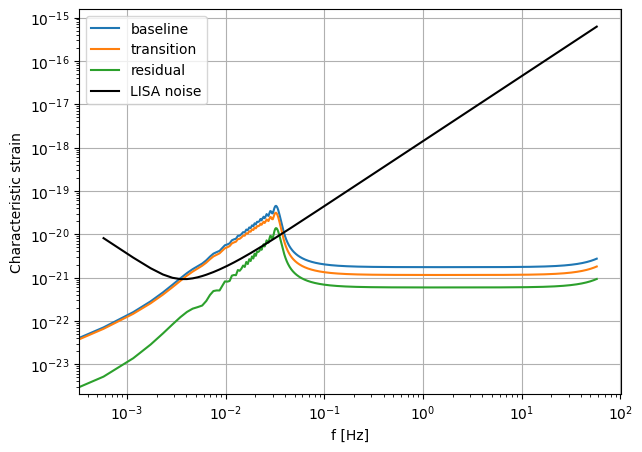

In [ ]:
# Plot characteristic strain in frequency domain
plt.figure(figsize=(7,5))

#Plot characteristic strains of the three waveforms
plt.loglog(freq, hc_baseline, label="baseline")
plt.loglog(freq, hc_transition, label="transition")
plt.loglog(freq, hc_residual, label="residual")

# Overlay LISA noise amplitude (sensitivity curve)
plt.loglog(freq, hn, label="LISA noise", color="black")

# Axis labels and formatting 
plt.xlabel("f [Hz]")
plt.ylabel("Characteristic strain")
plt.legend()
plt.grid()

# Save the figure to a file and display the plot
plt.savefig("frequency_strain.png", dpi=300)
plt.show()


## Waveform mismatch

In [20]:
# Calculation of noise-weighted inner product and mismatch
def inner_product(a,b,Sn,f):
    """
    Compute the noise-weighted inner product between two frequency-domain waveforms.
    <a|b> = 4 * Re[ ∫ (a(f) * conj(b(f))) / Sn(f) df ]
    """
    mask = f>0
    integrand = (a[mask]*np.conj(b[mask]))/Sn[mask]

    val = 4*np.real(np.trapz(integrand,f[mask]))

    return val

def mismatch(h1,h2,Sn,f):
    """
    Compute the waveform mismatch: 1 - overlap, where
    overlap = |<h1|h2>| / sqrt(<h1|h1> * <h2|h2>)
    """
    n1 = inner_product(h1,h1,Sn,f)
    n2 = inner_product(h2,h2,Sn,f)

    ip = inner_product(h1,h2,Sn,f)

    overlap = ip/np.sqrt(n1*n2)

    return 1-overlap

In [21]:
# Compute mismatch between baseline and transition waveforms
mm = mismatch(H_baseline,H_transition,Sn,freq)

print("Waveform mismatch:",mm)


Waveform mismatch: 0.002986218719360445


C:\Users\sunyx\AppData\Local\Temp\ipykernel_15992\166660704.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = 4*np.real(np.trapz(integrand,f[mask]))


## Save SNR results

In [22]:
# Save all computed results to a text file
with open("snr_results.txt","w") as f:

    f.write(f"Baseline SNR: {snr_baseline}\n")
    f.write(f"Transition SNR: {snr_transition}\n")
    f.write(f"Residual SNR: {snr_residual}\n")
    f.write(f"Waveform mismatch: {mm}\n")

print("Results saved to snr_results.txt")


Results saved to snr_results.txt
